In [1]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict, Annotated

from langchain_groq import ChatGroq
from langchain_ollama import ChatOllama
from langchain.messages import RemoveMessage, HumanMessage
from dotenv import load_dotenv

from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

load_dotenv()

True

In [2]:
summary_llm = ChatGroq(model="meta-llama/llama-4-scout-17b-16e-instruct")
llm = ChatOllama(model="qwen3.5:9b")

In [3]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage],add_messages]
    summary: str

def summarize_chat_history(state: ChatState):

    existing_summary = state['summary']

    if existing_summary:
        prompt = (
            f"Existing Summary: {existing_summary}\n\n"
            "Extend the summary using new conversation above"
        )
    else:
        prompt = "Summarizmessage_for_summarye the conversation above."

    message_for_summary = state['messages'] + [HumanMessage(content=prompt)]

    response = summary_llm.invoke(message_for_summary)

    msg_to_delete = state['messages'][:-2]

    return {
        'messages': [RemoveMessage(id=msg.id) for msg in msg_to_delete],
        'summary': response.content,
    }

def get_response(state: ChatState):
    messages = []
    if state['summary']:
        messages.append({
            "role":"system",
            "content": f"Conversation Summary: \n{state['summary']}"
        })

    messages.extend(state['messages'])

    print(messages)

    prompt = f"Keep the reponse length within 200 words for belows query: \n\n{messages}"

    response = llm.invoke(messages)

    return {'messages': [response]}

def condition_to_summarize(state: ChatState):
    return len(state['messages']) > 6

In [4]:
builder = StateGraph(ChatState)

builder.add_node('response',get_response)
builder.add_node('summarize',summarize_chat_history)

builder.add_edge(START, "response")
builder.add_conditional_edges(
    "response",
    condition_to_summarize,
    {
        True: "summarize",
        False: "__end__",
    }
)

builder.add_edge("summarize", "__end__")

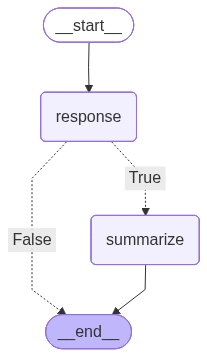

In [5]:
cp = InMemorySaver()

chatbot = builder.compile(checkpointer=cp)
chatbot

In [6]:
config = {'configurable':{"thread_id":"Chat_1"}}
def run(text:str):
    result = chatbot.invoke({'messages':[HumanMessage(content=text)], 'summary':""}, config=config)
    return result

def show_state():
    snap = chatbot.get_state(config=config)
    vals = snap.values
    print("\n---STATE---")
    print("Summary:",vals.get("summary",[]))
    print("Messages Length:",len(vals.get("messages",[])))
    print("Messages:\n")

    for msg in vals.get("messages",[]):
        print('-', type(msg).__name__,':',msg.content[:100])

In [7]:
run("Define FIP.")
show_state()

[HumanMessage(content='Define FIP.', additional_kwargs={}, response_metadata={}, id='36f064d8-65da-4ea9-8cf1-6442fe75a054')]

---STATE---
Summary: 
Messages Length: 2
Messages:

- HumanMessage : Define FIP.
- AIMessage : The acronym **FIP** can refer to several different concepts depending on the industry or field of di


In [8]:
run("How it is a dangerous disease.")
show_state()

[HumanMessage(content='Define FIP.', additional_kwargs={}, response_metadata={}, id='36f064d8-65da-4ea9-8cf1-6442fe75a054'), AIMessage(content='The acronym **FIP** can refer to several different concepts depending on the industry or field of discussion. Here are the most common definitions:\n\n### 1. Veterinary Medicine (Most Common Usage)\n*   **Full Term:** **Feline Infectious Peritonitis**\n*   **Description:** A serious, often fatal viral disease in cats caused by a mutation of feline coronavirus (FCoV). It affects the kidneys and liver, leading to fluid accumulation around organs or abdomen. There are two forms: "dry" FIP (granulomatous inflammation) and "wet" FIP (effusive/hydro-pericardium/pleural effusion).\n*   **Context:** Commonly searched by pet owners regarding cat health symptoms.\n\n### 2. Information Technology & Law (Privacy Compliance)\n*   **Full Term:** **Fair Information Practices** (or Principles / Policies)\n*   **Description:** A framework of guidelines for mana

In [9]:
run("Is it a curable disease?")
show_state()

[HumanMessage(content='Define FIP.', additional_kwargs={}, response_metadata={}, id='36f064d8-65da-4ea9-8cf1-6442fe75a054'), AIMessage(content='The acronym **FIP** can refer to several different concepts depending on the industry or field of discussion. Here are the most common definitions:\n\n### 1. Veterinary Medicine (Most Common Usage)\n*   **Full Term:** **Feline Infectious Peritonitis**\n*   **Description:** A serious, often fatal viral disease in cats caused by a mutation of feline coronavirus (FCoV). It affects the kidneys and liver, leading to fluid accumulation around organs or abdomen. There are two forms: "dry" FIP (granulomatous inflammation) and "wet" FIP (effusive/hydro-pericardium/pleural effusion).\n*   **Context:** Commonly searched by pet owners regarding cat health symptoms.\n\n### 2. Information Technology & Law (Privacy Compliance)\n*   **Full Term:** **Fair Information Practices** (or Principles / Policies)\n*   **Description:** A framework of guidelines for mana

In [10]:
run("Which cat breeds are more prune to such disease?")
show_state()

[HumanMessage(content='Define FIP.', additional_kwargs={}, response_metadata={}, id='36f064d8-65da-4ea9-8cf1-6442fe75a054'), AIMessage(content='The acronym **FIP** can refer to several different concepts depending on the industry or field of discussion. Here are the most common definitions:\n\n### 1. Veterinary Medicine (Most Common Usage)\n*   **Full Term:** **Feline Infectious Peritonitis**\n*   **Description:** A serious, often fatal viral disease in cats caused by a mutation of feline coronavirus (FCoV). It affects the kidneys and liver, leading to fluid accumulation around organs or abdomen. There are two forms: "dry" FIP (granulomatous inflammation) and "wet" FIP (effusive/hydro-pericardium/pleural effusion).\n*   **Context:** Commonly searched by pet owners regarding cat health symptoms.\n\n### 2. Information Technology & Law (Privacy Compliance)\n*   **Full Term:** **Fair Information Practices** (or Principles / Policies)\n*   **Description:** A framework of guidelines for mana

In [11]:
run("Top 5 cats breeds as per their size.")
show_state()

[HumanMessage(content='Which cat breeds are more prune to such disease?', additional_kwargs={}, response_metadata={}, id='6159a177-74c1-435f-a7e2-5fb81780a07c'), AIMessage(content='Based on current veterinary research, there is **no strong scientific evidence suggesting that specific cat breeds are genetically more prone to developing Feline Infectious Peritonitis (FIP)** compared to others.\n\nIn other words: A Siamese has no greater genetic susceptibility than a Persian or a Mixed-Breed tabby regarding the development of clinical disease once infected with Coronavirus. However, there is nuance regarding *environment* that often leads people to believe certain breeds are higher risk. Here is the breakdown:\n\n### 1. The Genetic Reality (Breed Does Not Matter)\nFIP depends on an individual cat\'s immune system responding abnormally to a specific mutation of the Feline Coronavirus (FCoV). This reaction appears random among individuals, not linked to breed DNA markers like coat color or 

In [14]:
run("different foods for good dental health.")
show_state()

[HumanMessage(content='Which cat breeds are more prune to such disease?', additional_kwargs={}, response_metadata={}, id='6159a177-74c1-435f-a7e2-5fb81780a07c'), AIMessage(content='Based on current veterinary research, there is **no strong scientific evidence suggesting that specific cat breeds are genetically more prone to developing Feline Infectious Peritonitis (FIP)** compared to others.\n\nIn other words: A Siamese has no greater genetic susceptibility than a Persian or a Mixed-Breed tabby regarding the development of clinical disease once infected with Coronavirus. However, there is nuance regarding *environment* that often leads people to believe certain breeds are higher risk. Here is the breakdown:\n\n### 1. The Genetic Reality (Breed Does Not Matter)\nFIP depends on an individual cat\'s immune system responding abnormally to a specific mutation of the Feline Coronavirus (FCoV). This reaction appears random among individuals, not linked to breed DNA markers like coat color or 

In [13]:
chatbot.get_state(config).values['messages']

[HumanMessage(content='Which cat breeds are more prune to such disease?', additional_kwargs={}, response_metadata={}, id='6159a177-74c1-435f-a7e2-5fb81780a07c'),
 AIMessage(content='Based on current veterinary research, there is **no strong scientific evidence suggesting that specific cat breeds are genetically more prone to developing Feline Infectious Peritonitis (FIP)** compared to others.\n\nIn other words: A Siamese has no greater genetic susceptibility than a Persian or a Mixed-Breed tabby regarding the development of clinical disease once infected with Coronavirus. However, there is nuance regarding *environment* that often leads people to believe certain breeds are higher risk. Here is the breakdown:\n\n### 1. The Genetic Reality (Breed Does Not Matter)\nFIP depends on an individual cat\'s immune system responding abnormally to a specific mutation of the Feline Coronavirus (FCoV). This reaction appears random among individuals, not linked to breed DNA markers like coat color or